# Gene enrichment, split by immediate vs. previous response gene sets
I've done enrichment analyses for some of the phase 2 comparisons (see [gsea](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/gsea_p2.v.p2.ipynb) and [ora](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/ora_p2.v.p2.ipynb)), but I have over 50 pairwise comparisons and it's hard to go through results by looking at everything at once. 

In a [previous notebook](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/upset_p2.v.p2.ipynb) I compared DEGs between pairwise comparisons that differed by their most recent exposure (same phase 1, different phase 2) or by their previous exposure (different phase 2, same phase 1). The list of comparisons can be found [here](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/imm_prev_datasets.csv).

In this notebook, I'm going to dig into the gene annotation and enrichment for these datasets to think more broadly about what processes are enriched due to the previous vs. immediate response to enviornmental stress.

## 0. load libraries

In [52]:
library(tidyverse)

# enrichment analysis 
library(clusterProfiler) # for GSEA()
library(enrichplot) # for enrichment visuals
library(GO.db) # for gene ontology database
library(fgsea) # fast pre-ranked GSEA

# visualizing
library(patchwork) # add multiple plots together
library(RColorBrewer) 
library(ggh4x)

## 1. read.csvs

### comparisons of interest

In [3]:
im.prev <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/imm_prev_datasets.csv')

dim(im.prev)
head(im.prev)

[1] 96 16

,dataset,total_genes,deg_numb,phase1,phase2,expr_high,comparison,DEG_count,results,stress_set,is_outlier,xaxis,comp1,comp2,lower,diff_treatment
,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,bc_bb,204,31,B,C,BC,BC vs. BB,204,Immediate Exposure,Both,FALSE,"Same phase 1, different phase 2",bc,bb,bc vs. bb,Control
2,bc_bb,204,173,B,B,BB,BC vs. BB,204,Immediate Exposure,Both,FALSE,"Same phase 1, different phase 2",bc,bb,bc vs. bb,Both
3,bc_cc,281,187,B,C,BC,BC vs. CC,281,Previous Exposure,Control,TRUE,"Different phase 1, same phase 2",bc,cc,bc vs. cc,Both
4,bc_cc,281,94,C,C,CC,BC vs. CC,281,Previous Exposure,Control,TRUE,"Different phase 1, same phase 2",bc,cc,bc vs. cc,Control
5,bc_hc,134,35,B,C,BC,BC vs. HC,134,Previous Exposure,Control,FALSE,"Different phase 1, same phase 2",bc,hc,bc vs. hc,Both
6,bc_hc,134,99,H,C,HC,BC vs. HC,134,Previous Exposure,Control,FALSE,"Different phase 1, same phase 2",bc,hc,bc vs. hc,Hypoxic


### deseq results

In [4]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/',
    pattern = '\\.csv$',
    full.names = TRUE
    )

head(files)

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq//bb_cc.csv"
[2] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq//bc_bb.csv"
[3] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq//bc_cc.csv"
[4] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq//bc_hc.csv"
[5] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq//bc_wc.csv"
[6] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq//bh_bb.csv"

In [5]:
names(files) <- tools::file_path_sans_ext(basename(files))
df_list <- lapply(files, read.csv)
names(df_list)
length(df_list)

[1] "bb_cc"        "bc_bb"        "bc_cc"        "bc_hc"        "bc_wc"       
 [6] "bh_bb"        "bh_bc"        "bh_bw"        "bh_ch"        "bh_hh"       
[11] "bw_bb"        "bw_bc"        "bw_cw"        "bw_ww"        "cb_bb"       
[16] "cb_bc"        "cb_cc"        "cb_ch"        "cb_cw"        "ch_cc"       
[21] "ch_hc"        "cw_cc"        "cw_ch"        "cw_wc"        "hb_bb"       
[26] "hb_bh"        "hb_cb"        "hb_hc"        "hb_hh"        "hb_hw"       
[31] "hc_cc"        "hc_hh"        "hh_cc"        "hh_ch"        "hw_bw"       
[36] "hw_cw"        "hw_hc"        "hw_hh"        "hw_ww"        "vst_filtered"
[41] "wb_bb"        "wb_bw"        "wb_cb"        "wb_hb"        "wb_wc"       
[46] "wb_wh"        "wb_ww"        "wc_cc"        "wc_hc"        "wc_ww"       
[51] "wh_bh"        "wh_ch"        "wh_hh"        "wh_hw"        "wh_wc"       
[56] "wh_ww"        "ww_cc"        "ww_cw"

[1] 58

keep only the comparisons that match the dataset of interest

In [6]:
head(basename(files))
head(im.prev$dataset)

[1] "bb_cc.csv" "bc_bb.csv" "bc_cc.csv" "bc_hc.csv" "bc_wc.csv" "bh_bb.csv"

[1] "bc_bb" "bc_bb" "bc_cc" "bc_cc" "bc_hc" "bc_hc"

In [7]:
wanted_files <- files[tools::file_path_sans_ext(basename(files)) %in% im.prev$dataset]
head(wanted_files)

bc_bb 
"/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq//bc_bb.csv" 
                                                                                                                                               bc_cc 
"/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq//bc_cc.csv" 
                                                                                                                                               bc_hc 
"/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq//bc_hc.csv" 
                                                                                                                                               bc_wc 
"/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq//bc_wc.csv" 
                                                                                                                                               bh_bb 
"/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq//bh_bb.csv" 
                                                                                                                                               bh_bc 
"/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq//bh_bc.csv"

In [8]:
res_list <- lapply(wanted_files, data.table::fread)
names(res_list)
length(names(res_list))

[1] "bc_bb" "bc_cc" "bc_hc" "bc_wc" "bh_bb" "bh_bc" "bh_bw" "bh_ch" "bh_hh"
[10] "bw_bb" "bw_bc" "bw_cw" "bw_ww" "cb_bb" "cb_cc" "cb_ch" "cb_cw" "ch_cc"
[19] "cw_cc" "cw_ch" "hb_bb" "hb_cb" "hb_hc" "hb_hh" "hb_hw" "hc_cc" "hc_hh"
[28] "hh_ch" "hw_bw" "hw_cw" "hw_hc" "hw_hh" "hw_ww" "wb_bb" "wb_cb" "wb_hb"
[37] "wb_wc" "wb_wh" "wb_ww" "wc_cc" "wc_hc" "wc_ww" "wh_bh" "wh_ch" "wh_hh"
[46] "wh_wc" "wh_ww" "ww_cw"

[1] 48

split dfs by results (immediate vs. previous exposure)

In [9]:
uniq_im.prev <- distinct(im.prev, dataset, .keep_all = TRUE)
dim(uniq_im.prev)

[1] 48 16

In [10]:
groups <- split(uniq_im.prev$dataset, uniq_im.prev$results)          
res_by_group <- lapply(groups, function(ds) res_list[ds])

names(res_by_group) # this is a list of lists

[1] "Immediate Exposure" "Previous Exposure"

In [11]:
# check 24 comparisons in each group
length(res_by_group$'Immediate Exposure')
length(res_by_group$'Previous Exposure')

[1] 24

[1] 24

### gene annotations and ontology

In [12]:
# col1 = gene ID
# col2 = GO ID 
gene2go <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/Reference_genomes/Cvirginica_genome/annotations/newRef_geneGO.csv')
head(gene2go)

,gene,Gene.Ontology.IDs
,<chr>,<chr>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655
2,LOC111099032,GO:0004930;GO:0005886;GO:0007186
3,LOC111099037,GO:0000978;GO:0000981;GO:0006355
4,LOC111099039,GO:0004930;GO:0005886;GO:0007189
5,LOC111099040,GO:0005515;GO:0007169;GO:0035556
6,LOC111099041,GO:0016020;GO:0022857;GO:0055085


re-format for correct input for `GSEA()` - two columns, one for GO term and one for gene ID

In [13]:
term2gene <- gene2go %>%
  mutate(GO_terms = strsplit(Gene.Ontology.IDs, ",\\s*|;\\s*|`")) %>%  # Split by comma, semicolon, or backtick
  unnest(GO_terms) %>%
  filter(grepl("^GO:", GO_terms)) %>%  # Keep only valid GO terms
  dplyr::select(term = GO_terms, gene = gene)

class(term2gene)
str(term2gene)
head(term2gene)

[1] "tbl_df"     "tbl"        "data.frame"

tibble [39,588 × 2] (S3: tbl_df/tbl/data.frame)
 $ term: chr [1:39588] "GO:0005261" "GO:0005886" "GO:0030001" "GO:0098655" ...
 $ gene: chr [1:39588] "LOC111099029" "LOC111099029" "LOC111099029" "LOC111099029" ...


term,gene
<chr>,<chr>
GO:0005261,LOC111099029
GO:0005886,LOC111099029
GO:0030001,LOC111099029
GO:0098655,LOC111099029
GO:0004930,LOC111099032
GO:0005886,LOC111099032


get term names for GO IDs

In [14]:
# Extract GO term descriptions
go_terms <- unique(term2gene$term)

# Get descriptions from GO.db
term2name <- data.frame(
  term = go_terms,
  name = sapply(go_terms, function(x) {
    tryCatch({
      Term(GOTERM[[x]])
    }, error = function(e) {
      NA_character_
    })
  })
)

# Remove NAs
term2name <- term2name[!is.na(term2name$name), ]

# View
head(term2name)    

,term,name
,<chr>,<chr>
GO:0005261,GO:0005261,monoatomic cation channel activity
GO:0005886,GO:0005886,plasma membrane
GO:0030001,GO:0030001,metal ion transport
GO:0098655,GO:0098655,monoatomic cation transmembrane transport
GO:0004930,GO:0004930,G protein-coupled receptor activity
GO:0007186,GO:0007186,G protein-coupled receptor signaling pathway


## 2. GSEA
Are pathways generally over- or under-expressed in a given treatment?

I want to compile enrichment results for response due to immediate treatment vs previous treatment. Based on previous analysis with some of these comparisons (see [here](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/gsea_p2.v.p2.ipynb)), I'm expecting the majority of comparisons will have any enriched GO terms.

GSEA requires a ranked gene list - ranking by log2FoldChange most to least

In [31]:
# used Claude to optimize this code from another notebook for a nested df list
make_ranks <- function(df) {
    # remove genes with NAs and duplicated genes
    df <- df[!is.na(df$log2FoldChange) & !is.na(df$V1), ]
    df <- df[!duplicated(df$V1), ]
    # get ranked order 
    geneList <- setNames(df$log2FoldChange, df$V1)
    sort(geneList, decreasing = TRUE)
}

all_df <- lapply(res_by_group, function(group) lapply(group, make_ranks))

# check
head(all_df$'Immediate Exposure'$bc_bb)

LOC111110380 LOC111109782 LOC144618073 LOC144621807 LOC144623744 LOC111127506 
    22.79584     21.77722     20.83270     18.42000     16.69036     16.53306

now want to run GSEA on every pairwise comparion, keeping the copmarison groups separate and storing the results in a df 

this code is originally from a previous notebook (see [gsea](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/gsea_p2.v.p2.ipynb)) but was optimized for efficiency with Claude

In [33]:
set.seed(42)   # sets .Random.seed and makes results reproducible

run_gsea <- function(geneList) {
    res <- tryCatch(
        GSEA(
            geneList = geneList,
            TERM2GENE = term2gene,
            TERM2NAME = term2name,
            pvalueCutoff = 0.05,
            verbose = FALSE
        ),
        error = function(e) {
            message("GSEA failed: ", conditionMessage(e))
            NULL
        }
    )
    if (is.null(res)) return(NULL)
    as.data.frame(res)
}

gsea_list <- lapply(all_df, function(group) lapply(group, run_gsea))

gsea_df <- bind_rows(lapply(names(gsea_list), function(g) {
    bind_rows(gsea_list[[g]], .id = "comparison") |>
        mutate(exposure = g, .before = 1)
}))

count(gsea_df, exposure, comparison)

no term enriched under specific pvalueCutoff...

no term enriched under specific pvalueCutoff...

no term enriched under specific pvalueCutoff...

no term enriched under specific pvalueCutoff...

no term enriched under specific pvalueCutoff...

no term enriched under specific pvalueCutoff...

no term enriched under specific pvalueCutoff...

no term enriched under specific pvalueCutoff...

no term enriched under specific pvalueCutoff...

no term enriched under specific pvalueCutoff...

no term enriched under specific pvalueCutoff...

no term enriched under specific pvalueCutoff...

no term enriched under specific pvalueCutoff...

no term enriched under specific pvalueCutoff...

no term enriched under specific pvalueCutoff...

no term enriched under specific pvalueCutoff...

no term enriched under specific pvalueCutoff...

no term enriched under specific pvalueCutoff...

no term enriched under specific pvalueCutoff...

no term enriched under specific pvalueCutoff...

no term enriched und

exposure,comparison,n
<chr>,<chr>,<int>
Immediate Exposure,hc_hh,2
Previous Exposure,bw_ww,1
Previous Exposure,wc_cc,1
Previous Exposure,wc_hc,1


okay so only 4 pairwise comparisons have enriched GO terms, and only 1 of them is in a comparison with DEGs that are due to the most immediate exposure

In [34]:
gsea_list$'Immediate Exposure'$hc_hh

,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>
GO:0008061,GO:0008061,chitin binding,48,0.991411,1.802265,8.25038e-07,0.0004001434,0.0004001434,1,"tags=2%, list=0%, signal=2%",LOC144619016


In [35]:
gsea_list$'Previous Exposure'$bw_ww

,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>
GO:0009898,GO:0009898,cytoplasmic side of plasma membrane,11,0.9901312,2.015868,8.902883e-05,0.04317898,0.04317898,8,"tags=9%, list=0%, signal=9%",LOC144619407


In [36]:
gsea_list$'Previous Exposure'$wc_cc

,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
GO:0030425,GO:0030425,dendrite,15,-0.9996268,-1.561878,4.629488e-05,0.02245302,0.02245302,7,"tags=13%, list=0%, signal=13%",LOC144622761/LOC111127528


In [37]:
gsea_list$'Previous Exposure'$wc_hc

,ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue,rank,leading_edge,core_enrichment
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
GO:0030425,GO:0030425,dendrite,15,-0.999647,-1.571491,1.592753e-06,0.0007724854,0.0007724854,8,"tags=13%, list=0%, signal=13%",LOC144622761/LOC111127528


## 3. ORA
Are there any gene sets that are over-represented in the identified differential expressed genes (DEGs) than would be expected by chance?

ORA input is a gene list (DEGs) and a universal list (list of all genes that could be a DEG)

first need to grab DEGs from each pairwise comparison

In [15]:
deg_list <- lapply(res_by_group, function(group) {
    lapply(group, function(df) {
        df |>
            filter(!is.na(padj), abs(log2FoldChange) >= 1, padj <= 0.05) |>
            pull(V1)          # gene ID column: V1 earlier, Gene here. Use whichever your dfs have
    })
})


length(deg_list$'Previous Exposure')


[1] 24

create universal list for each pairwise comparison (all possible genes that can be DEGs, excluding NAs)

In [16]:
universe_list <- lapply(res_by_group, function(group) {
    lapply(group, function(df) {
        df |>
            filter(!is.na(padj)) |>
            pull(V1) |>
            unique()
    })
})

In [17]:
names(universe_list$'Immediate Exposure')

[1] "bc_bb" "bh_bb" "bh_bc" "bh_bw" "bw_bb" "bw_bc" "cb_cc" "cb_ch" "cb_cw"
[10] "ch_cc" "cw_cc" "cw_ch" "hb_hc" "hb_hh" "hb_hw" "hc_hh" "hw_hc" "hw_hh"
[19] "wb_wc" "wb_wh" "wb_ww" "wc_ww" "wh_wc" "wh_ww"

In [21]:
run_ora <- function(genes, universe) {
    res <- tryCatch(
        enricher(
            gene = genes,
            TERM2GENE = term2gene,
            TERM2NAME = term2name,
            pvalueCutoff = 0.05,
            pAdjustMethod = "BH",
            universe = universe
        ),
        error = function(e) {
            message("ORA failed: ", conditionMessage(e))
            NULL
        }
    )
    if (is.null(res)) return(NULL)
    as.data.frame(res)
}

# Pair each group/comparison with its matching universe
ora_list <- Map(function(group_genes, group_univ) {
    Map(run_ora, group_genes, group_univ[names(group_genes)])
}, deg_list, universe_list[names(deg_list)])

# Combine into one df
ora_df <- bind_rows(lapply(names(ora_list), function(g) {
    bind_rows(ora_list[[g]], .id = "comparison") |>
        mutate(exposure = g, .before = 1)
}))

count(ora_df, exposure, comparison)

exposure,comparison,n
<chr>,<chr>,<int>
Immediate Exposure,bc_bb,7
Immediate Exposure,bh_bb,8
Immediate Exposure,bh_bc,10
Immediate Exposure,bh_bw,5
Immediate Exposure,bw_bc,6
Immediate Exposure,cb_cc,15
Immediate Exposure,cb_cw,1
Immediate Exposure,ch_cc,9
Immediate Exposure,cw_cc,17


In [22]:
head(ora_df)

,exposure,comparison,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0008234...1,Immediate Exposure,bc_bb,GO:0008234,cysteine-type peptidase activity,4/68,20/10381,7.538629e-06,0.0003844701,0.0003253513,LOC111113029/LOC111113025/LOC111113028/LOC111113026,4
GO:0006869...2,Immediate Exposure,bc_bb,GO:0006869,lipid transport,4/68,28/10381,3.062535e-05,0.0006448911,0.0005457283,LOC144619407/LOC144622387/LOC144622389/LOC111138228,4
GO:0005615...3,Immediate Exposure,bc_bb,GO:0005615,extracellular space,10/68,318/10381,3.793477e-05,0.0006448911,0.0005457283,LOC111105325/LOC144625661/LOC144620089/LOC111125328/LOC144622709/LOC111125415/LOC111126666/LOC144623871/LOC111111632/LOC111111873,10
GO:0006508...4,Immediate Exposure,bc_bb,GO:0006508,proteolysis,7/68,171/10381,1.211533e-04,0.0015447050,0.0013071807,LOC111113029/LOC111113025/LOC111113028/LOC111113026/LOC111134528/LOC111137950/LOC111128165,7
GO:0005576...5,Immediate Exposure,bc_bb,GO:0005576,extracellular region,6/68,205/10381,2.180179e-03,0.0218532187,0.0184929198,LOC144622387/LOC144622389/LOC144622709/LOC111125217/LOC111106396/LOC111106155,6
GO:0004867...6,Immediate Exposure,bc_bb,GO:0004867,serine-type endopeptidase inhibitor activity,3/68,42/10381,2.570967e-03,0.0218532187,0.0184929198,LOC111111632/LOC111111516/LOC111132135,3


In [34]:
head(im.prev)

,dataset,total_genes,deg_numb,phase1,phase2,expr_high,comparison,DEG_count,results,stress_set,is_outlier,xaxis,comp1,comp2,lower,diff_treatment
,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,bc_bb,204,31,B,C,BC,BC vs. BB,204,Immediate Exposure,Both,FALSE,"Same phase 1, different phase 2",bc,bb,bc vs. bb,Control
2,bc_bb,204,173,B,B,BB,BC vs. BB,204,Immediate Exposure,Both,FALSE,"Same phase 1, different phase 2",bc,bb,bc vs. bb,Both
3,bc_cc,281,187,B,C,BC,BC vs. CC,281,Previous Exposure,Control,TRUE,"Different phase 1, same phase 2",bc,cc,bc vs. cc,Both
4,bc_cc,281,94,C,C,CC,BC vs. CC,281,Previous Exposure,Control,TRUE,"Different phase 1, same phase 2",bc,cc,bc vs. cc,Control
5,bc_hc,134,35,B,C,BC,BC vs. HC,134,Previous Exposure,Control,FALSE,"Different phase 1, same phase 2",bc,hc,bc vs. hc,Both
6,bc_hc,134,99,H,C,HC,BC vs. HC,134,Previous Exposure,Control,FALSE,"Different phase 1, same phase 2",bc,hc,bc vs. hc,Hypoxic


In [72]:
# add stress set info
ora.data <- merge(im.prev %>% dplyr::select('comparison' = dataset, stress_set), ora_df, by = 'comparison') %>%
mutate(exposure2 = case_when(
    exposure == 'Immediate Exposure' ~ 'Same phase 1, different phase 2',
    exposure == 'Previous Exposure' ~ 'Different phase 1, same phase 2'))

# set factor levels
ora.data$exposure2 <- factor(ora.data$exposure2, levels = c('Same phase 1, different phase 2', 'Different phase 1, same phase 2'))
ora.data$stress_set <- factor(ora.data$stress_set, levels = c('Control', 'Hypoxic', 'Warm', 'Both'))

head(ora.data)

,comparison,stress_set,exposure,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,exposure2
,<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<fct>
1,bc_bb,Both,Immediate Exposure,GO:0008234,cysteine-type peptidase activity,4/68,20/10381,7.538629e-06,0.0003844701,0.0003253513,LOC111113029/LOC111113025/LOC111113028/LOC111113026,4,"Same phase 1, different phase 2"
2,bc_bb,Both,Immediate Exposure,GO:0006869,lipid transport,4/68,28/10381,3.062535e-05,0.0006448911,0.0005457283,LOC144619407/LOC144622387/LOC144622389/LOC111138228,4,"Same phase 1, different phase 2"
3,bc_bb,Both,Immediate Exposure,GO:0005615,extracellular space,10/68,318/10381,3.793477e-05,0.0006448911,0.0005457283,LOC111105325/LOC144625661/LOC144620089/LOC111125328/LOC144622709/LOC111125415/LOC111126666/LOC144623871/LOC111111632/LOC111111873,10,"Same phase 1, different phase 2"
4,bc_bb,Both,Immediate Exposure,GO:0006508,proteolysis,7/68,171/10381,1.211533e-04,0.0015447050,0.0013071807,LOC111113029/LOC111113025/LOC111113028/LOC111113026/LOC111134528/LOC111137950/LOC111128165,7,"Same phase 1, different phase 2"
5,bc_bb,Both,Immediate Exposure,GO:0005576,extracellular region,6/68,205/10381,2.180179e-03,0.0218532187,0.0184929198,LOC144622387/LOC144622389/LOC144622709/LOC111125217/LOC111106396/LOC111106155,6,"Same phase 1, different phase 2"
6,bc_bb,Both,Immediate Exposure,GO:0004867,serine-type endopeptidase inhibitor activity,3/68,42/10381,2.570967e-03,0.0218532187,0.0184929198,LOC111111632/LOC111111516/LOC111132135,3,"Same phase 1, different phase 2"


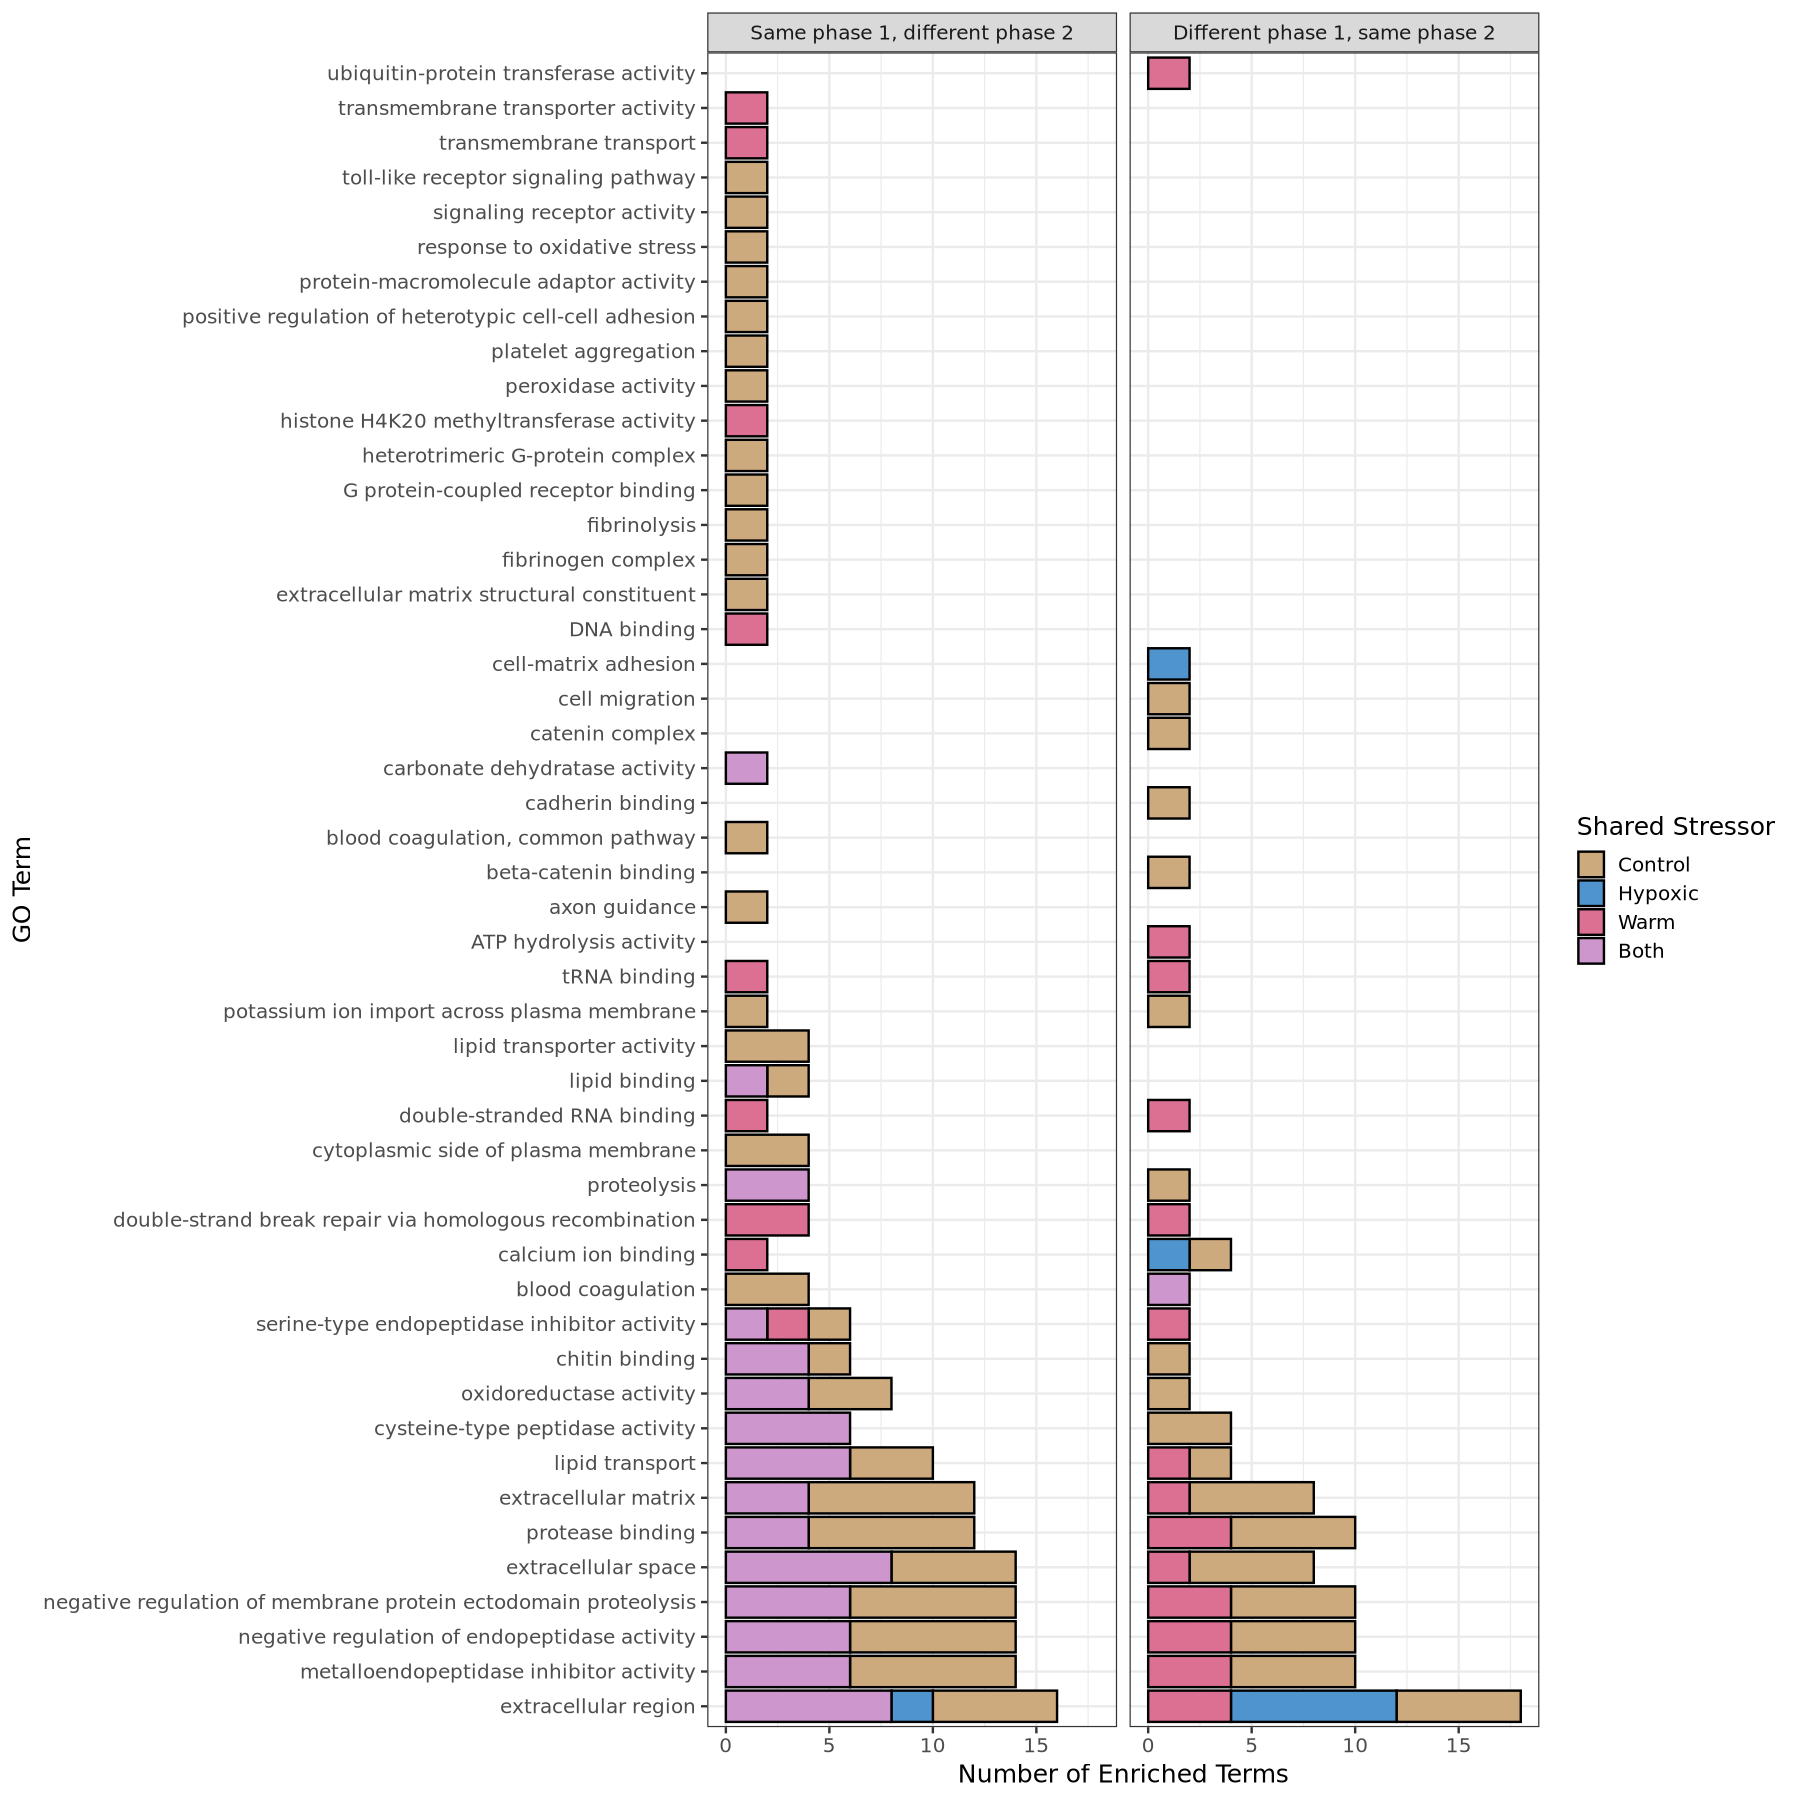

In [73]:
options(repr.plot.height = 15, repr.plot.width = 15)

ggplot(ora.data, aes(x = fct_infreq(Description), fill = stress_set)) +
geom_bar(col = 'black') +
facet_wrap(~exposure2) +
  scale_fill_manual(values = c("Hypoxic" = "steelblue3",
                               "Warm" = "palevioletred",
                               "Control" = "burlywood3",
                               "Both" = "plum3")) +
theme_bw(base_size = 15) +
coord_flip() +
labs(fill = 'Shared Stressor',
    x = 'GO Term',
    y = 'Number of Enriched Terms')


**observations**:
- a lot of green - which are enriched terms between comparisons where control is the shared treatment - so there seems to be more enriched terms for comparisons that were both control at either phase 1 or 2

but losing what the differences are due to (what is the exact copmarison?)

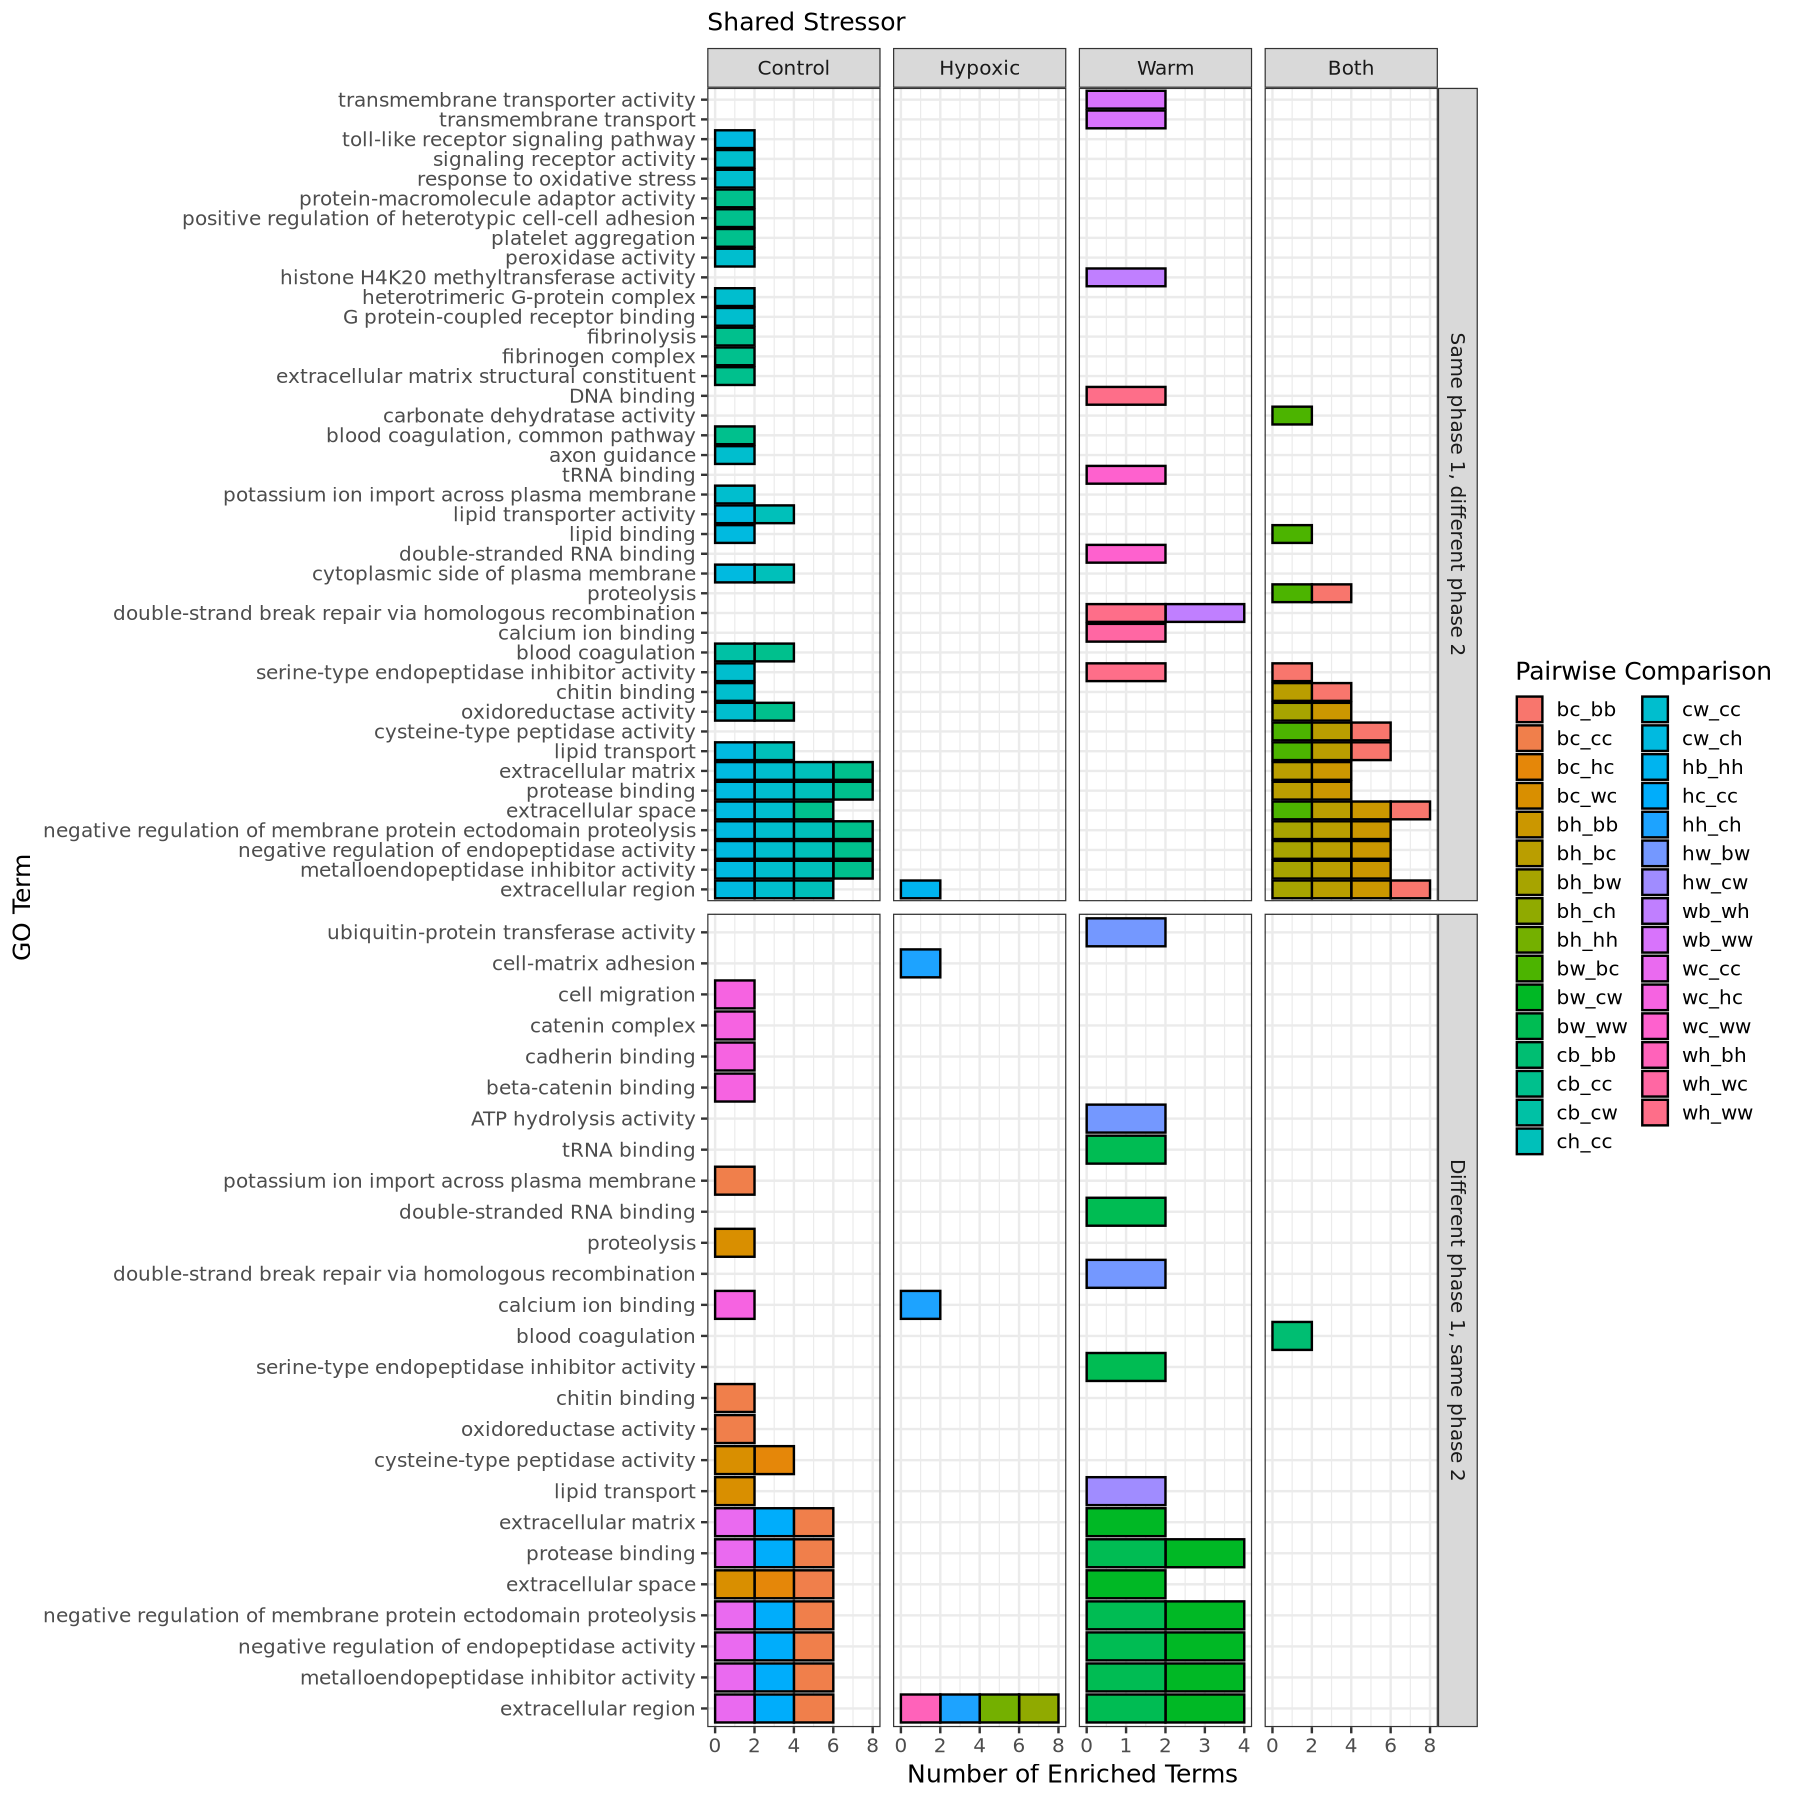

In [74]:
options(repr.plot.height = 15, repr.plot.width = 15)

ggplot(ora.data, aes(y = fct_infreq(Description), fill = comparison)) +
    geom_bar(col = "black") +
    facet_grid2(exposure2 ~ stress_set,
                scales = "free") +
    theme_bw(base_size = 15) +
    labs(fill = "Pairwise Comparison",
         y = "GO Term",
         x = "Number of Enriched Terms",
         subtitle = "Shared Stressor")


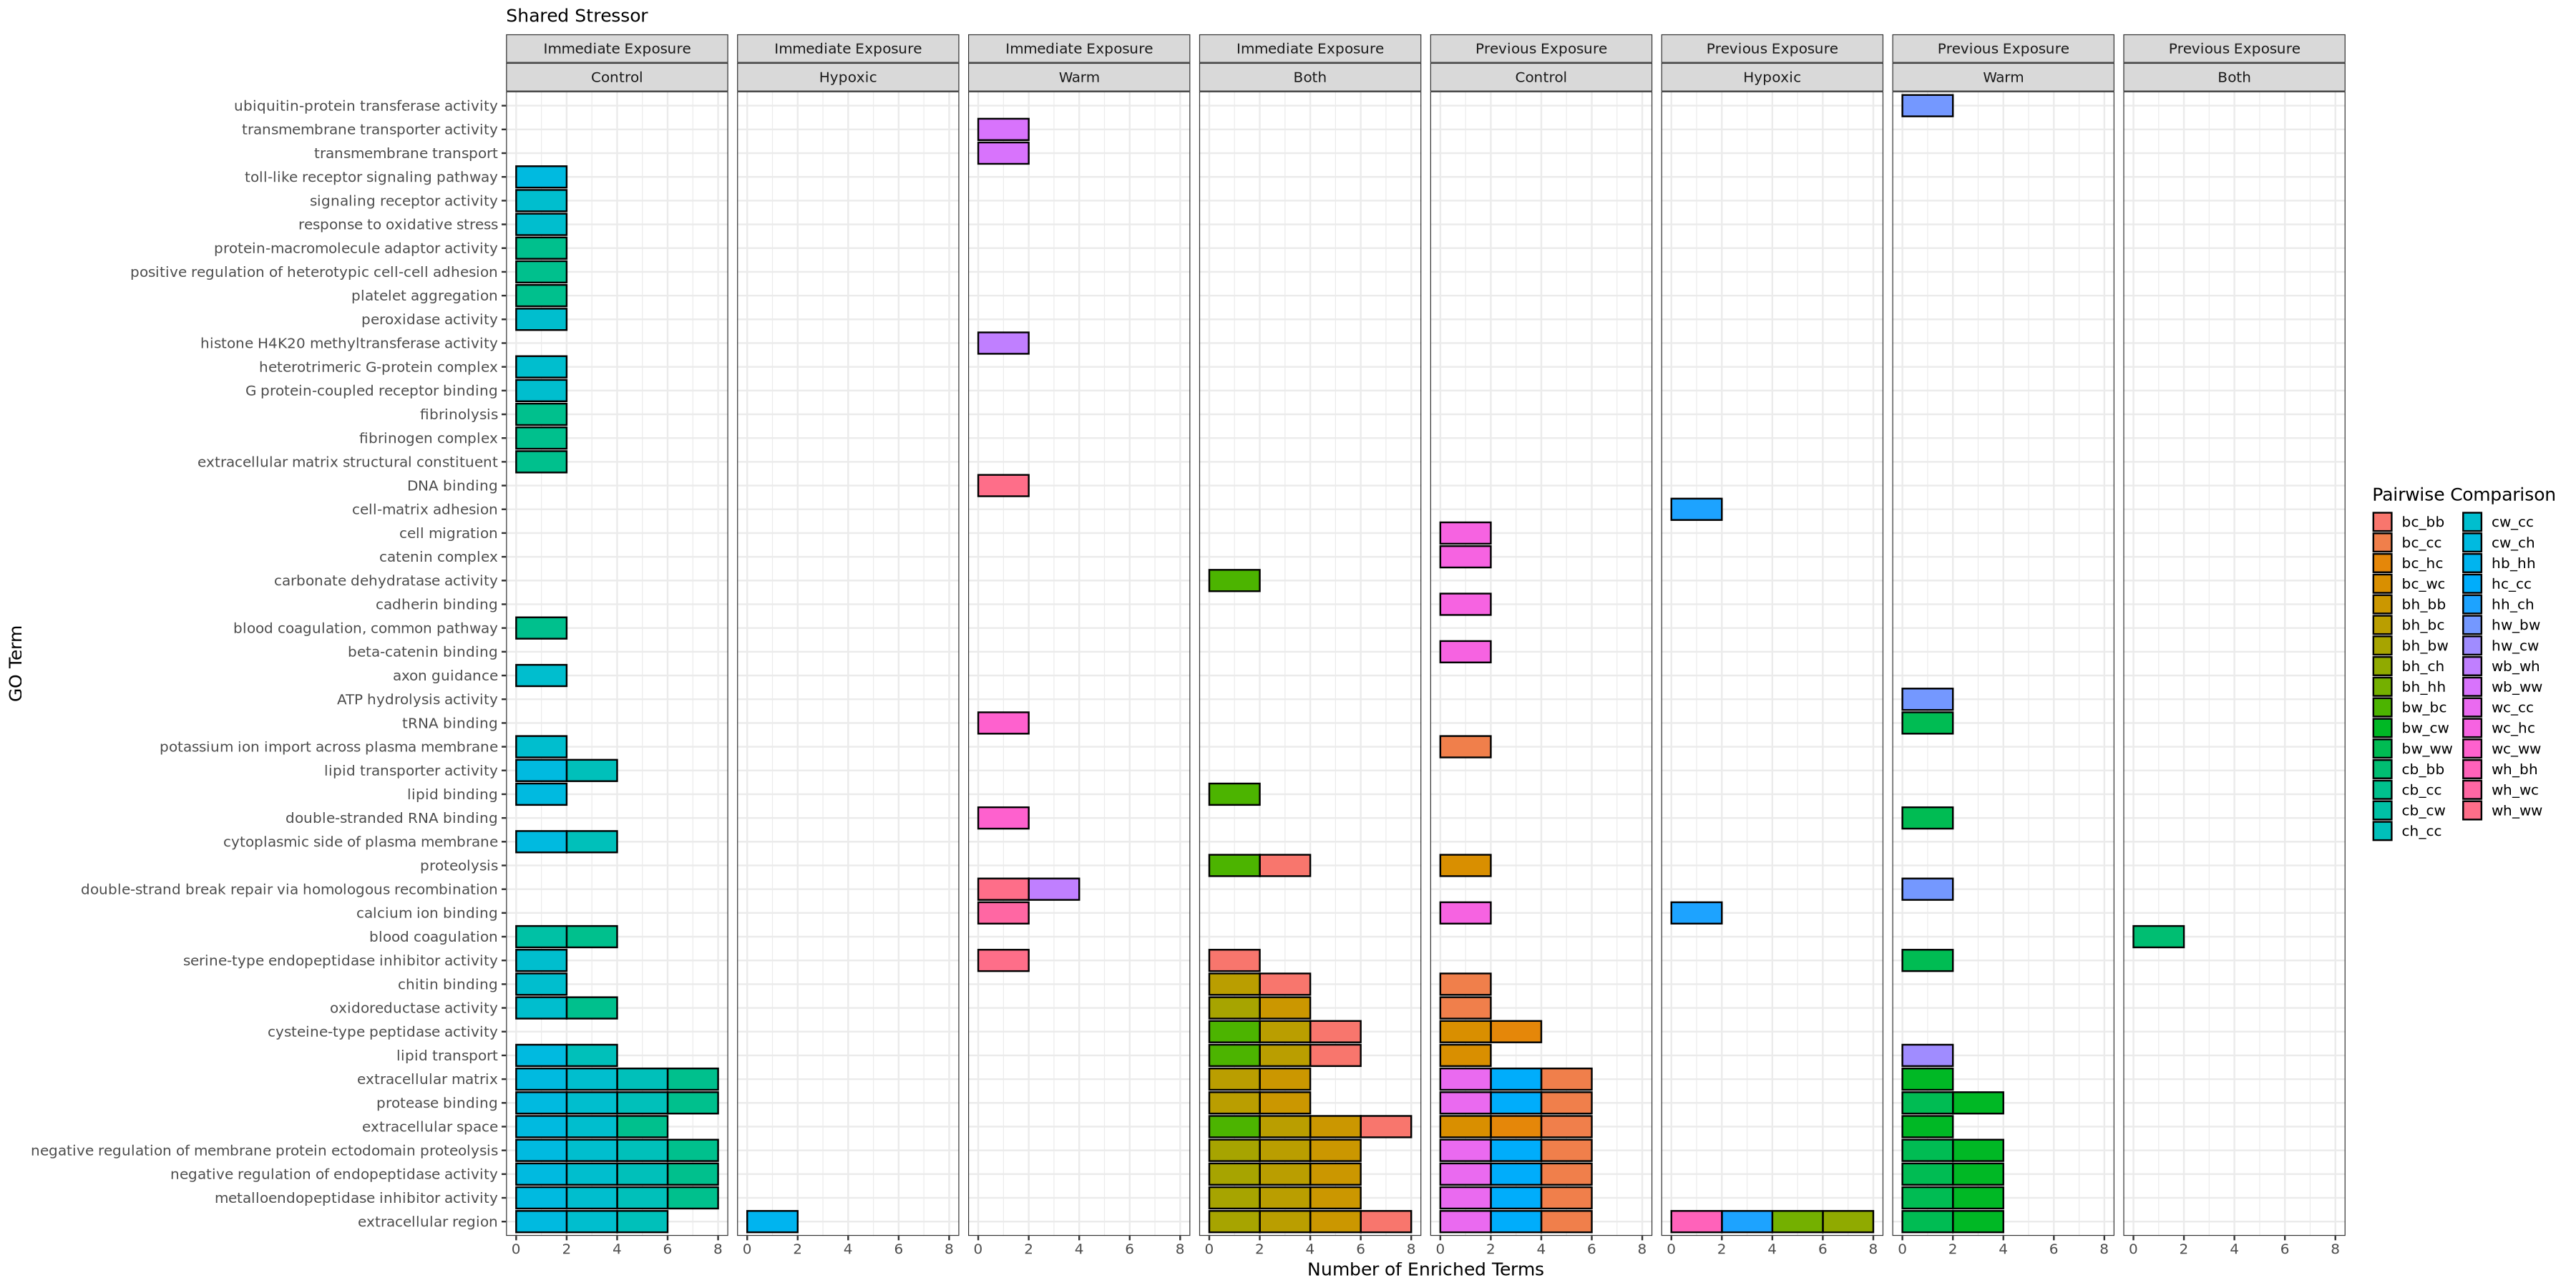

In [75]:
options(repr.plot.height = 15, repr.plot.width = 30)

ggplot(ora.data, aes(y = fct_infreq(Description), fill = comparison)) +
    geom_bar(col = "black") +
    facet_wrap(exposure ~ stress_set, nrow = 1) +
    theme_bw(base_size = 15) +
    labs(fill = "Pairwise Comparison",
         y = "GO Term",
         x = "Number of Enriched Terms",
         subtitle = "Shared Stressor")


**observations**:
- a lot of the same GO terms are enriched across the pairwise comparisons (bottom of the plots - mainly includes shared phase 1 control and both and shared phase 2 control and warm)
- top row: same phase 1 different phase 2 (so response is due to immediate exposure)
    - early life hypoxia = less enrichment
    - early life control = more variety in what GO terms are enriched